In [5]:
import os, re
import argparse

# import nest_asyncio
import numpy as np
import pandas as pd
import lightkurve as lk
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.io import fits
from tqdm import tqdm_notebook
from astrocut import CutoutFactory
# from ipywidgets import *
import matplotlib.colors as colors
from matplotlib import patches
from astropy.stats import sigma_clip
from glob import glob

from tess_asteroid_ml import *
from tess_asteroid_ml.make_TESS_asteroid_db import *
from tess_asteroid_ml.utils import in_cutout, power_find

from scipy.interpolate import RegularGridInterpolator

import pickle
import warnings
warnings.simplefilter('ignore')

In [6]:
from tess_asteroid_ml.make_TESScut_asteroids import *

In [7]:
def fit_bkg(tpf:lk.TessTargetPixelFile, polyorder:int=1) -> np.ndarray:
    """Fit a simple 2d polynomial background to a TPF
    
    Parameters
    ----------
    tpf: lightkurve.TessTargetPixelFile
        Target pixel file object
    polyorder: int
        Polynomial order for the model fit.
        
    Returns
    -------
    model : np.ndarray
        Model for background with same shape as tpf.shape
    """
    
    if not isinstance(tpf, lk.TessTargetPixelFile):
        raise ValueError("Input a TESS Target Pixel File")
    
    if (np.product(tpf.shape[1:]) < 100) | np.any(np.asarray(tpf.shape[1:]) < 6):
        raise ValueError("TPF too small. Use a bigger cut out.")
        
        
    # Grid for calculating polynomial
    R, C = np.mgrid[:tpf.shape[1], :tpf.shape[2]].astype(float)
    R -= tpf.shape[1]/2
    C -= tpf.shape[2]/2
    
    
    def func(tpf):
        # Design matrix
        A = np.vstack([R.ravel()**idx*C.ravel()**jdx for idx in range(polyorder + 1) for jdx in range(polyorder + 1)]).T
        
        # Median star image
        m = np.median(tpf.flux.value, axis=0)
        # Remove background from median star image
        mask = ~sigma_clip(m, sigma=3).mask.ravel()
        #plt.imshow(mask.reshape(m.shape))
        bkg0 = A.dot(np.linalg.solve(A[mask].T.dot(A[mask]), A[mask].T.dot(m.ravel()[mask]))).reshape(m.shape)
        
        m -= bkg0

        # Include in design matrix
        A = np.hstack([A, m.ravel()[:, None]])
        
        # Fit model to data, including a model for the stars
        f = np.vstack(tpf.flux.value.transpose([1, 2, 0]))
        ws = np.linalg.solve(A.T.dot(A), A.T.dot(f))
        
        # Build a model that is just the polynomial
        model = (A[:, :-1].dot(ws[:-1])).reshape((tpf.shape[1], tpf.shape[2], tpf.shape[0])).transpose([2, 0, 1])
        # model += bkg0
        return model
    
    # Break point for TESS orbit
    b = np.where(np.diff(tpf.cadenceno) == np.diff(tpf.cadenceno).max())[0][0] + 1
    
    # Calculate the model for each orbit, then join them
    model = np.vstack([func(tpf) for tpf in [tpf[:b], tpf[b:]]])
    return model

In [8]:
sector, camera, ccd = 1, 2, 1
provider = "mast"
maglim = 20

['https://archive.stsci.edu/missions/tess/ffi/s0001/2018/221/2-1/tess2018221072942-s0001-2-1-0120-s_ffic.fits']
Loading from CSV file: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/jpl/jpl_small_bodies_tess_s0001-2-0_catalog.csv
JPL SBI found 6161 asteroids with V < 30 in s0001-2-0
Asteroids in the catalog with V < 20 (1081, 22)


Total asteroids in hi-res DB (full cam): 560


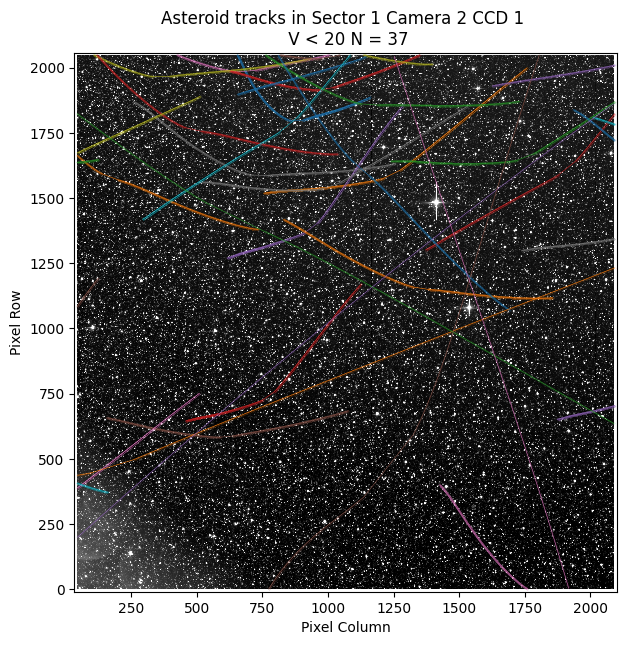

In [9]:
ffi_file = get_FFI_name(sector=sector, camera=camera, ccd=ccd, provider=provider, correct=False)
print(ffi_file)

# get FFI data to build ra/dec coordinates for later query

ffi_header, f2d, col_2d, row_2d, ra_2d, dec_2d = get_data_from_files(
    ffi_file, provider=provider
)
ffi_header = ffi_header[0]
f2d = f2d[0]
col_2d = col_2d
row_2d = row_2d
ra_2d = ra_2d[0]
dec_2d = dec_2d[0]

obs_time = Time([ffi_header["DATE-OBS"], ffi_header["DATE-END"]], format="isot")

jpl_df = get_asteroid_table(
    SkyCoord(ra_2d.min() * u.deg, dec_2d.min() * u.deg, frame='icrs'),
    SkyCoord(ra_2d.max() * u.deg, dec_2d.max() * u.deg, frame='icrs'),
    sector=sector,
    camera=camera,
    ccd=0,
    date_obs=obs_time.mean().jd,
)
if maglim <= 30:
    asteroid_df = jpl_df.query(f"V_mag <= {maglim}")
print(f"Asteroids in the catalog with V < {maglim}", asteroid_df.shape)

sb_ephems_hires = read_asteroid_db(
    asteroid_df, low_res=False, sector=sector, camera=camera, ccd=ccd
)
print(f"Total asteroids in hi-res DB (full cam): {len(sb_ephems_hires)}")

vlo, lo, mid, hi, vhi = np.nanpercentile(f2d, [0.2, 3, 50, 95, 99])
cnorm = colors.LogNorm(vmin=lo, vmax=vhi)

plt.figure(figsize=(7,7))
plt.pcolormesh(col_2d, row_2d, f2d, norm=cnorm, cmap="Greys_r")

counter = 0
for k, val in sb_ephems_hires.items():
    if len(val) == 0:
        continue
    val = val.query(f"camera == {camera} and ccd == {ccd}")
    if len(val) > 0: counter += 1
    plt.plot(val.column, val.row, ".-", ms=0.1, lw=.4)
    # if k == 1: break
plt.title(f"Asteroid tracks in Sector {sector} Camera {camera} CCD {ccd} \n "
          f"V < {maglim} N = {counter}")

plt.xlim(col_2d.min() - 10, col_2d.max() + 10)
plt.ylim(row_2d.min() - 10, row_2d.max() + 10)
# plt.gca().set_aspect('equal')
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.show()

In [10]:
cutout_size = 64
xcen, ycen = get_cutout_centers(sampling="tiled", overlap=4, size=cutout_size)
print(xcen, ycen, xcen.shape)

[[  34   94  154 ... 1894 1954 2014]
 [  34   94  154 ... 1894 1954 2014]
 [  34   94  154 ... 1894 1954 2014]
 ...
 [  34   94  154 ... 1894 1954 2014]
 [  34   94  154 ... 1894 1954 2014]
 [  34   94  154 ... 1894 1954 2014]] [[  34   34   34 ...   34   34   34]
 [  94   94   94 ...   94   94   94]
 [ 154  154  154 ...  154  154  154]
 ...
 [1894 1894 1894 ... 1894 1894 1894]
 [1954 1954 1954 ... 1954 1954 1954]
 [2014 2014 2014 ... 2014 2014 2014]] (34, 34)


In [12]:
cut_dict = {}
for j in xcen[0, :]:
    for i in ycen[:, 0]:
        if row_2d[i,j] < 2000:
                continue
        cut_dict[f"c{col_2d[i, j]:04}_r{row_2d[i,j]:04}"] = SkyCoord(
            ra_2d[i, j] * u.deg, dec_2d[i, j] * u.deg, frame="icrs"
        )
len(cut_dict)

34

In [13]:
cut_dict

{'c0078_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (318.21411842, -59.86065524)>,
 'c0138_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (318.84895789, -59.78861414)>,
 'c0198_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (319.48377893, -59.71328502)>,
 'c0258_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (320.11844287, -59.63459139)>,
 'c0318_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (320.75278852, -59.55248836)>,
 'c0378_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (321.38664081, -59.46695276)>,
 'c0438_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (322.01981734, -59.37797515)>,
 'c0498_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (322.65213306, -59.28555352)>,
 'c0558_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (323.28340349, -59.18968814)>,
 'c0618_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (323.91344671, -59.09037761)>,
 'c0678_r2014': <SkyCoord (ICRS): (ra, dec) in deg
     (324.54208435, -58.98761565)>,
 'c0738_r2014': <SkyCoord (ICRS): (ra, dec)

In [17]:
factory = CutoutFactory()
cube_file = (
    f"s3://stpubdata/tess/public/mast/tess-s{sector:04d}-{camera}-{ccd}-cube.fits"
)
cube_file

's3://stpubdata/tess/public/mast/tess-s0001-2-1-cube.fits'

In [18]:
cut_dict['c2058_r2014']

<SkyCoord (ICRS): (ra, dec) in deg
    (338.09107131, -55.33496612)>

In [21]:
i,j

(2014, 2014)

In [52]:
test = SkyCoord(ra_2d[i-20, j-20] * u.deg, 
                dec_2d[i-20, j-20] * u.deg, 
                frame="icrs")
test

<SkyCoord (ICRS): (ra, dec) in deg
    (338.02355789, -55.56316115)>

In [53]:
test.to_pixel(factory.cube_wcs, 1)

NoConvergence: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.

In [27]:
factory.cube_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 333.15069539989014  -63.67320689857164  
CRPIX : 1045.0  1001.0  
CD1_1 CD1_2  : 0.005197000500886899  -0.002483667402886  
CD2_1 CD2_2  : 0.002353082758702  0.005138475689528924  
NAXIS : 2136  2078

In [56]:
from astrocut.exceptions import InputWarning, InvalidQueryError

In [57]:
try:
    factory.cube_cut(
        cube_file=cube_file,
        coordinates=test,
        cutout_size=cutout_size,
        target_pixel_file="./data/border_test.fits",
        threads="auto",
    )
except InvalidQueryError:
    print("fail")

fail


In [7]:
tpf_names = np.sort(glob(f"{os.path.dirname(PACKAGEDIR)}/data/tesscuts/sector{sector:04}/TESScut_s{sector:04}-{camera}-{ccd}_c*_r*_64x64pix.fits"))
len(tpf_names)

1156

In [8]:
offset_row = pd.read_csv(f"{os.path.dirname(PACKAGEDIR)}/data/support/position_offsets/source_position_offset_row.csv", header=[0,1])
offset_col = pd.read_csv(f"{os.path.dirname(PACKAGEDIR)}/data/support/position_offsets/source_position_offset_column.csv", header=[0,1])

In [9]:
interp_col = RegularGridInterpolator((offset_col.loc[:, ("column", "column")].values.reshape(20,20)[:, 0],
                                  offset_col.loc[:, ("row", "row")].values.reshape(20,20)[0, :]),
                                 offset_col.loc[:, (str(camera), str(ccd))].values.reshape(20,20),
                                 method="slinear", 
                                 bounds_error=False, 
                                 fill_value=None,
                                )

interp_row = RegularGridInterpolator((offset_row.loc[:, ("column", "column")].values.reshape(20,20)[:, 0],
                                  offset_row.loc[:, ("row", "row")].values.reshape(20,20)[0, :]),
                                 offset_row.loc[:, (str(camera), str(ccd))].values.reshape(20,20),
                                 method="slinear", 
                                 bounds_error=False, 
                                 fill_value=None,
                                )

In [19]:
offset_row

row  column         1                                       2  \
        row  column         3         4         2         1         3   
0      50.0    95.0 -0.888758 -0.783748 -0.886331 -0.997788 -0.952803   
1     150.0    95.0 -0.882883 -0.814659 -0.898741 -0.984086 -0.929255   
2     250.0    95.0 -0.844510 -0.785592 -0.902827 -0.974555 -0.942510   
3     350.0    95.0 -0.840262 -0.780905 -0.897872 -0.951959 -0.930034   
4     450.0    95.0 -0.833449 -0.818896 -0.906465 -0.935136 -0.922824   
..      ...     ...       ...       ...       ...       ...       ...   
395  1550.0  1995.0 -0.979624 -0.927224 -0.963447 -1.003509 -0.992044   
396  1650.0  1995.0 -0.991715 -0.931021 -0.969451 -0.983595 -0.994881   
397  1750.0  1995.0 -0.992132 -0.922721 -0.971021 -1.010486 -0.995443   
398  1850.0  1995.0 -0.991905 -0.926223 -0.968538 -1.015878 -0.997136   
399  1950.0  1995.0 -1.014246 -0.919440 -0.964219 -1.023731 -1.002656   

                                          3                                \
            4         2         1         1         2         4         3   
0   -0.931133 -0.788789 -0.951235 -1.001682 -0.893554 -0.926565 -0.953085   
1   -0.929055 -0.768278 -0.939994 -0.971687 -0.930041 -0.938686 -0.971327   
2   -0.921568 -0.788442 -0.918604 -0.921407 -0.895291 -0.949264 -0.970331   
3   -0.889330 -0.801010 -0.894773 -0.914426 -0.901147 -0.956384 -0.969235   
4   -0.915265 -0.797143 -0.886378 -0.904137 -0.920211 -0.950901 -0.976542   
..        ...       ...       ...       ...       ...       ...       ...   
395 -0.994598 -0.985843 -1.001277 -0.997931 -0.969831 -0.947192 -0.999271   
396 -0.996095 -0.988189 -1.001752 -0.987712 -0.977355 -0.940746 -1.008369   
397 -1.004308 -0.984687 -0.992792 -1.006530 -0.985054 -0.946249 -1.007272   
398 -1.003431 -0.975379 -1.005113 -1.007878 -0.978638 -0.957937 -1.005273   
399 -1.019276 -0.964184 -1.014025 -1.016466 -0.993572 -0.955887 -1.013545   

            4                                
            1         2         4         3  
0   -1.090335 -1.023615 -0.732342 -0.938198  
1   -1.084059 -1.023052 -0.741749 -0.886236  
2   -1.074980 -1.028137 -0.736806 -0.868432  
3   -1.060185 -1.016117 -0.740322 -0.837185  
4   -1.054823 -1.014713 -0.733725 -0.821346  
..        ...       ...       ...       ...  
395 -1.067116 -1.049198 -0.879774 -0.919795  
396 -1.078650 -1.059013 -0.883132 -0.927426  
397 -1.074832 -1.058897 -0.883925 -0.936695  
398 -1.080498 -1.065568 -0.875318 -0.930086  
399 -1.086698 -1.075038 -0.879187 -0.941310  

[400 rows x 18 columns]

In [10]:
fine_grid_col, fine_grid_row = np.mgrid[0:2048, 44:2092]

In [11]:
fine_grid_col, fine_grid_row = np.mgrid[0:2048, 44:2092]
fine_eval = np.array([[c, r] for c, r in zip (fine_grid_col[::5, ::5].ravel(), fine_grid_row[::5, ::5].ravel())])

fine_value_col = interp_col(fine_eval)
fine_value_row = interp_row(fine_eval)

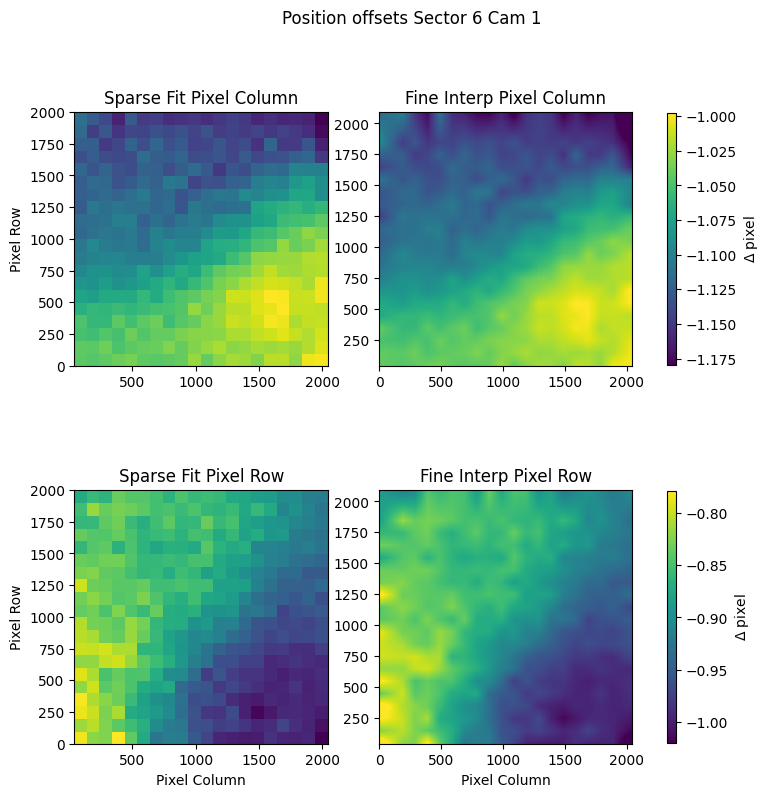

In [12]:
vlo, lo, mid, hi, vhi = np.nanpercentile(offset_col.loc[:, (str(camera), str(ccd))].values, [0.2, 1, 50, 95, 99.8])

fig, ax = plt.subplots(2,2, figsize=(9,9))
fig.suptitle(f"Position offsets Sector {sector} Cam {camera}", y=0.96)
ax[0, 0].set_title("Sparse Fit Pixel Column")
im = ax[0,0].pcolor(
    offset_col.loc[:, ("column", "column")].values.reshape(20,20),
    offset_col.loc[:, ("row", "row")].values.reshape(20,20),
    offset_col.loc[:, (str(camera), str(ccd))].values.reshape(20,20), 
    vmin=vlo,
    vmax=vhi,
)
ax[0, 1].set_title("Fine Interp Pixel Column")
ax[0, 1].pcolor(
    fine_grid_col[::5, ::5],
    fine_grid_row[::5, ::5],
    fine_value_col.reshape((410, 410)), 
    vmin=vlo,
    vmax=vhi,
    rasterized=True,
)

plt.colorbar(im, ax=ax[0], orientation="vertical", shrink=0.8, label=r"$\Delta$ pixel", aspect=30)

vlo, lo, mid, hi, vhi = np.nanpercentile(offset_row.loc[:, (str(camera), str(ccd))].values, [0.2, 1, 50, 95, 99.8])
ax[1, 0].set_title("Sparse Fit Pixel Row")
im = ax[1,0].pcolor(
    offset_row.loc[:, ("column", "column")].values.reshape(20,20),
    offset_row.loc[:, ("row", "row")].values.reshape(20,20),
    offset_row.loc[:, (str(camera), str(ccd))].values.reshape(20,20), 
    vmin=vlo,
    vmax=vhi,
)
ax[1, 1].set_title("Fine Interp Pixel Row")
ax[1, 1].pcolor(
    fine_grid_col[::5, ::5],
    fine_grid_row[::5, ::5],
    fine_value_row.reshape((410, 410)), 
    vmin=vlo,
    vmax=vhi,
    rasterized=True,
)

plt.colorbar(im, ax=ax[1], orientation="vertical", shrink=0.8, label=r"$\Delta$ pixel", aspect=30)

ax[0, 0].set_ylabel("Pixel Row")
ax[1, 0].set_ylabel("Pixel Row")
ax[1, 0].set_xlabel("Pixel Column")
ax[1, 1].set_xlabel("Pixel Column")

for axis in ax.ravel():
    axis.set_aspect('equal', 'box')



plt.show()

In [13]:
del fine_value_row, fine_value_col, fine_grid_col, fine_grid_row

In [166]:
sb_ephems_hires_corr = {}

for k, df in sb_ephems_hires.items():
    aux = df.copy()
    aux.column -= interp_col(aux[["column", "row"]].values)/2
    aux.row -= interp_row(aux[["column", "row"]].values)/2
    sb_ephems_hires_corr[k] = aux

In [167]:
sb_ephems_hires_corr[11] - sb_ephems_hires[11]

,time,sector,camera,ccd,column,row,pixels_per_hour,ra,dec,vmag,sun_distance,obs_distance,phase_angle
809,0.0,0,0,0,0.521196,0.384212,0.0,0.0,0.0,0.0,0.0,0.0,0.0
810,0.0,0,0,0,0.521209,0.384358,0.0,0.0,0.0,0.0,0.0,0.0,0.0
811,0.0,0,0,0,0.521221,0.384504,0.0,0.0,0.0,0.0,0.0,0.0,0.0
812,0.0,0,0,0,0.521234,0.384651,0.0,0.0,0.0,0.0,0.0,0.0,0.0
813,0.0,0,0,0,0.521247,0.384799,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,0.0,0,0,0,0.521958,0.393644,0.0,0.0,0.0,0.0,0.0,0.0,0.0
872,0.0,0,0,0,0.521969,0.393798,0.0,0.0,0.0,0.0,0.0,0.0,0.0
873,0.0,0,0,0,0.521981,0.393952,0.0,0.0,0.0,0.0,0.0,0.0,0.0
874,0.0,0,0,0,0.521992,0.394105,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
mask = []
for f in tpf_names:
    r = int(f.split("_")[-2][1:])
    c = int(f.split("_")[-3][1:])
    if r < 800 and r < 1300 and c > 600 and c < 1300:
        mask.append(True)
    else:
        mask.append(False)
mask = np.array(mask)
mask.sum()

156

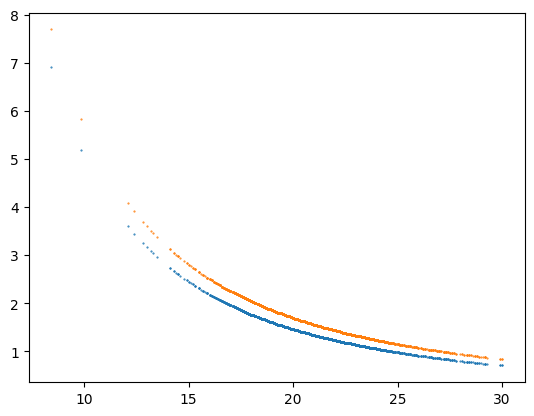

In [174]:
plt.plot(jpl_df.V_mag, 3.2e2 / (jpl_df.V_mag) ** 1.8, ".", ms=1)
plt.plot(jpl_df.V_mag, 3.2e2 / (jpl_df.V_mag) ** 1.75, ".", ms=1)

In [168]:
cube_flux = []
cube_mask_corr = []
cube_col = []
cube_row = []
asteroid_names = []

corr_pos = True

for tpf in tqdm(tpf_names[mask], total=len(tpf_names[mask])):

    fficut_aster = AsteroidTESScut(lk.read(tpf, quality_bitmask=None))
    if fficut_aster.row.min() > 600 and fficut_aster.column.min() > 600 :
        continue
    fficut_aster.ffi_exp_time = (ffi_header["TSTOP"] - ffi_header["TSTART"]) * 24 * 3600
    fficut_aster.get_CBVs(align=False, interpolate=True)
    fficut_aster.get_quaternions_and_angles()
    if fit_bkg:
        fficut_aster.fit_background(polyorder=3, positive_flux=True)
    
    for k in sb_ephems_hires.keys():
        if len(sb_ephems_hires[k]) <= 1:
            continue
        # check if asteroid track passes over the TESScut
        is_in = in_cutout(
            fficut_aster.column,
            fficut_aster.row,
            sb_ephems_hires[k].column.values,
            sb_ephems_hires[k].row.values,
        )
        if is_in:
            source_rad = 3.2e2 / (sb_ephems_hires[k].vmag.mean()) ** 1.71
            fficut_aster.get_asteroid_mask(
                sb_ephems_hires_corr[k] if corr_pos else sb_ephems_hires[k],
                name=asteroid_df.loc[k, ["Object name", "V_mag"]],
                mask_type="circular",
                mask_radius=source_rad,
                mask_num_type="index",
            )
    cube_flux.append(fficut_aster.flux_2d)
    cube_mask_corr.append(fficut_aster.asteroid_mask_2d)
    cube_col.append(fficut_aster.column_2d)
    cube_row.append(fficut_aster.row_2d)
    if hasattr(fficut_aster, "asteroid_names"):
        asteroid_names.append(fficut_aster.asteroid_names)
    else:
        asteroid_names.append({})

cube_flux = np.asarray(cube_flux)
cube_mask_corr = np.asarray(cube_mask_corr)
cube_col = np.asarray(cube_col)
cube_row = np.asarray(cube_row)

100%|██████████████████████████████████████████████████████████████████████████████| 156/156 [06:16<00:00,  2.41s/it]


In [169]:
cube_mask.shape, cube_mask_corr.shape

((123, 981, 64, 64), (123, 981, 64, 64))

# Plot Asteroid Mask

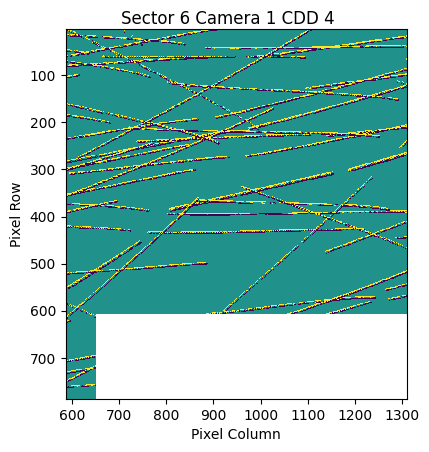

In [170]:
fig, ax = plt.subplots(1, 1)#, sharex=True, sharey=True)
fig.suptitle(f"Sector {sector} Camera {camera} CDD {ccd}", y=0.92)

for k in range(len(cube_mask_corr)):
    # ax.set_title(f"vmax = {1}")
    ax.pcolormesh(cube_col[k], 
                  cube_row[k],
                  cube_mask[k].sum(axis=0) - cube_mask_corr[k].sum(axis=0),
                  cmap="viridis",
                   vmin=-1,
                   vmax=1,
           )
ax.set_aspect('equal', 'box')
ax.invert_yaxis()

ax.set_xlabel("Pixel Column")
ax.set_ylabel("Pixel Row")

plt.show()

# Visualize track on a cutout

In [66]:
from numpy.lib.stride_tricks import sliding_window_view

In [164]:
def build_static(cube, window=50):
    nt, nx, ny = cube.shape
    df = pd.DataFrame(cube.reshape(nt, nx*ny))
    rmed = df.rolling(window).median().values.reshape(nt, nx, ny)
    med = np.median(cube[:window], axis=0)
    rmed[:window-1] = np.repeat(med.reshape(-1, nx, ny), window-1, axis=0)
    return rmed

In [172]:
cube_n = 121
frame = 0

statics = np.median(cube_flux[cube_n], axis=0)
vlo, lo, mid, hi, vhi = np.nanpercentile(cube_flux[cube_n] - statics, [0.2, 1, 5, 99, 99.8])

# median_win = np.concatenate([np.repeat(np.median(x, axis=0).reshape(-1, 64, 64), repeats=np.ceil(cube_flux[cube_n].shape[0]/10).astype(int), axis=0) for x in np.array_split(cube_flux[cube_n], 10)], axis=0)

median_win = build_static(cube_flux[cube_n], window=50)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
fig.suptitle(f"Asteroid tracks in TESScut \n Sector {sector} Camera {camera} CCD {ccd} \n Frame {frame} TJD {fficut_aster.time[frame]:.3f}", 
             y=0.98)
ima = ax.pcolormesh(cube_col[cube_n], 
                    cube_row[cube_n],
                    cube_flux[cube_n][frame] - median_win[frame],
                   cmap="Greys_r",
                   # norm=colors.SymLogNorm(linthresh=1000, vmin=100, vmax=2500, base=10),
                    vmin=mid,
                    vmax=hi,
                   )
plt.colorbar(
    ima, ax=ax, label=r"Flux ($e^{-}s^{-1}$)", fraction=0.042
    )

for i in range(fficut_aster.cutout_size):
    for j in range(fficut_aster.cutout_size):
        if cube_mask[cube_n, frame, i, j]:
            rect = patches.Rectangle(
                xy=(j + cube_col[cube_n].min() - 0.5, i + cube_row[cube_n].min() - 0.5),
                width=1,
                height=1,
                color="tab:red",
                fill=False,
                hatch="",
                alpha=.5
            )
            ax.add_patch(rect)
        if cube_mask_corr[cube_n, frame, i, j]:
            rect = patches.Rectangle(
                xy=(j + cube_col[cube_n].min() - 0.5, i + cube_row[cube_n].min() - 0.5),
                width=1,
                height=1,
                color="tab:green",
                fill=False,
                hatch="",
                alpha=.5
            )
            ax.add_patch(rect)

for k in asteroid_names[cube_n].keys():
    ax.plot(sb_ephems_hires[k].column, 
             sb_ephems_hires[k].row, 
             ".-", 
             ms=1,
             alpha=.5,
             label=asteroid_df.loc[k, "Object name"])

ax.set_xlim(cube_col[cube_n].min() - 4,cube_col[cube_n].max() + 4)
ax.set_ylim(cube_row[cube_n].min() - 4,cube_row[cube_n].max() + 4)
ax.set_aspect("equal")
ax.set_xlabel("Pixel Column")
ax.set_ylabel("Pixel Row")
ax.legend(loc='center right', bbox_to_anchor=(1.7, 0.1))

plt.close(ax.figure)

@widgets.interact(frame=(0, fficut_aster.time.shape[0]-1, 2))
def update(frame=0):
    
    fig.suptitle(f"Asteroid tracks in TESScut \n "
                 f"Sector {sector} Camera {camera} CCD {ccd} \n "
                 f"Frame {frame} TJD {fficut_aster.time[frame]:.3f}", 
y=0.98)
    
    ima = ax.pcolormesh(cube_col[cube_n], 
                        cube_row[cube_n],
                        cube_flux[cube_n][frame] - median_win[frame],
                        cmap="Greys_r",
                        # norm=colors.SymLogNorm(linthresh=1000, vmin=100, vmax=2500, base=10),
                        vmin=mid,
                        vmax=hi,
                   )
    for i in range(fficut_aster.cutout_size):
        for j in range(fficut_aster.cutout_size):
            if cube_mask[cube_n, frame, i, j]:
                rect = patches.Rectangle(
                    xy=(j + cube_col[cube_n].min() - 0.5, i + cube_row[cube_n].min() - 0.5),
                    width=1,
                    height=1,
                    color="tab:red",
                    fill=False,
                    hatch="",
                    alpha=.5
                )
                ax.add_patch(rect)
            if cube_mask_corr[cube_n, frame, i, j]:
                rect = patches.Rectangle(
                    xy=(j + cube_col[cube_n].min() - 0.5, i + cube_row[cube_n].min() - 0.5),
                    width=1,
                    height=1,
                    color="tab:green",
                    fill=False,
                    hatch="",
                    alpha=.5
                )
                ax.add_patch(rect)
    

    return fig

# plt.show()

interactive(children=(IntSlider(value=0, description='frame', max=980, step=2), Output()), _dom_classes=('widg…

# Find offsets from data

In [154]:
from scipy import ndimage
from scipy import sparse
import functools
from scipy.interpolate import CubicSpline

In [504]:
# only use asteroids in the cutout
ast_in_cut = pd.concat([pd.DataFrame.from_dict(x, orient="index") for x in asteroid_names]).drop_duplicates().sort_index()
ast_in_cut.head()

,Object name,V_mag
11,871 Amneris (A917 JD),15.9
16,1333 Cevenola (1934 DA),14.3
18,1651 Behrens (1936 HD),14.9
26,2161 Grissom (1963 UD),15.7
43,4105 Tsia (1989 EK),17.5


In [529]:
track_from_data = {}
cube_shape = cube_mask[0].shape
nt, npix = cube_shape[0], cube_shape[1]*cube_shape[2]

for aid in tqdm_notebook(ast_in_cut.index.values, total=ast_in_cut.index.values.shape[0], desc="Asteroid"):
    track_from_data[aid] = []
    for cdx in tqdm_notebook(range(len(cube_mask)), total=len(cube_mask), desc="Cutouts", leave=False):

        # make a master frame
        static = np.median(cube_flux[cdx], axis=0)

        # mask pixels with stars that can throw off the centroids
        star_mask = ~sigma_clip(static).mask
        # dilate mask to be sure
        star_mask = ndimage.binary_dilation(star_mask, iterations=3).ravel()
        # get the asteroid mask as sparse
        ast_p_mask = sparse.csr_matrix(cube_mask[cdx].reshape(nt, npix) == aid)
        # remove star pixels
        # print(ast_p_mask.shape, star_mask.shape)
        ast_p_mask = ast_p_mask.multiply(star_mask).tocsr()

        # compute weights from flux array
        wgts = ast_p_mask.multiply((cube_flux[cdx] - static).reshape(nt, npix)).tocsr()
        #compute pixel values with te pixel mask
        col_vals = ast_p_mask.multiply(cube_col[cdx].ravel()).tocsr()
        row_vals = ast_p_mask.multiply(cube_row[cdx].ravel()).tocsr()

        # compute centroids
        track_col = np.empty(nt) * np.nan
        track_row = np.empty(nt) * np.nan
        
        for t in range(lcube_shape[0]):
            if len(col_vals[t].data) > 0 and len(wgts[t].data) > 0 and wgts[t].data.sum() > 0:
                # print("row", row_vals[t].data, "col", col_vals[t].data, "wgts", wgts[t].data)
                track_col[t] = np.average(col_vals[t].data, weights=wgts[t].data)
                track_row[t] = np.average(row_vals[t].data, weights=wgts[t].data)
        df = pd.DataFrame(np.array([fficut_aster.time, track_col, track_row]).T, columns=["time", "column", "row"], index=np.arange(nt))
        track_from_data[aid].append(df)

        # break
    # break

Asteroid:   0%|          | 0/42 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

...

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

Cutouts:   0%|          | 0/90 [00:00<?, ?it/s]

In [531]:
centroids_dict = {}
for aid in track_from_data.keys():
    merge = pd.concat(track_from_data[aid])
    centroids_dict[aid] = merge.groupby(merge.index).mean()

In [532]:
offsets = {}
for aid in centroids_dict.keys():
    measured = centroids_dict[aid].dropna()
    if len(measured) == 0:
        continue
    _colf = CubicSpline(sb_ephems_hires[aid].time.values, sb_ephems_hires[aid].column)
    _rowf = CubicSpline(sb_ephems_hires[aid].time.values, sb_ephems_hires[aid].row)
    # mask with intersection of times between track as tess cut
    ti = np.where(measured.time >= sb_ephems_hires[aid].time.values[0])[0][0]
    # if ti > 0:
    #     ti -= 1
    tf = np.where(measured.time >= sb_ephems_hires[aid].time.values[-1])[0]
    if len(tf) > 0:
        tf = tf[0]
    else:
        tf = len(measured.time)
    tmask = np.zeros_like(measured.time, dtype=bool)
    tmask[ti:tf] = True
    # interpolate
    col_int = np.zeros_like(measured.time)
    row_int = np.zeros_like(measured.time)
    col_int[tmask] = _colf(measured.time[tmask])
    row_int[tmask] = _rowf(measured.time[tmask])

    expected = pd.DataFrame(np.array([measured.time, col_int, row_int]).T, columns=["time", "column", "row"], index=measured.index)
    offsets[aid] = expected - measured

In [533]:
dcol = []
drow = []
for df in offsets.values():
    dcol.extend(df.column.values)
    drow.extend(df.row.values)
dcol = np.array(dcol)
drow = np.array(drow)

In [537]:
offset_col

row  column         1                                       2  \
        row  column         3         4         2         1         3   
0      50.0    95.0 -0.900569 -1.043725 -1.047078 -0.930167 -0.786339   
1     150.0    95.0 -0.896180 -1.042718 -1.048048 -0.928856 -0.793272   
2     250.0    95.0 -0.865563 -1.051547 -1.054204 -0.924306 -0.790095   
3     350.0    95.0 -0.854105 -1.049525 -1.064165 -0.915495 -0.820713   
4     450.0    95.0 -0.842897 -1.064296 -1.068023 -0.910927 -0.822564   
..      ...     ...       ...       ...       ...       ...       ...   
395  1550.0  1995.0 -1.009292 -1.100490 -1.140255 -1.033164 -0.982720   
396  1650.0  1995.0 -1.017010 -1.148423 -1.144987 -1.021943 -0.982979   
397  1750.0  1995.0 -1.021288 -1.162483 -1.145899 -1.025315 -0.993801   
398  1850.0  1995.0 -1.017946 -1.175215 -1.103858 -1.023641 -0.984303   
399  1950.0  1995.0 -1.026653 -1.196332 -1.128440 -1.019490 -0.990050   

                                          3                                \
            4         2         1         1         2         4         3   
0   -0.914562 -1.146265 -1.047484 -1.055817 -1.184748 -0.910250 -0.886683   
1   -0.919699 -1.157147 -1.034085 -1.042669 -1.180340 -0.901333 -0.895127   
2   -0.928616 -1.168146 -1.016590 -1.042920 -1.181503 -0.903472 -0.861730   
3   -0.930729 -1.167168 -1.015750 -1.036237 -1.194282 -0.911710 -0.863099   
4   -0.945851 -1.197143 -1.023707 -1.038609 -1.189659 -0.919407 -0.862046   
..        ...       ...       ...       ...       ...       ...       ...   
395 -0.981504 -1.185252 -1.086968 -1.122838 -1.194771 -0.933301 -0.949459   
396 -1.014304 -1.233841 -1.095218 -1.124003 -1.226899 -0.970133 -0.954471   
397 -1.005707 -1.219429 -1.081505 -1.110691 -1.215057 -0.980739 -0.962280   
398 -1.042472 -1.255152 -1.087661 -1.121038 -1.224876 -0.987398 -0.960794   
399 -1.035149 -1.297670 -1.089876 -1.123744 -1.230984 -1.004483 -0.962813   

            4                                
            1         2         4         3  
0   -0.958426 -0.928016 -1.064029 -1.084626  
1   -0.950476 -0.932636 -1.071948 -1.046426  
2   -0.933603 -0.937964 -1.070237 -1.027802  
3   -0.915551 -0.940521 -1.080959 -1.026431  
4   -0.916140 -0.941633 -1.082710 -1.033010  
..        ...       ...       ...       ...  
395 -1.018019 -0.981152 -1.097566 -1.098162  
396 -1.020369 -0.971276 -1.112005 -1.083553  
397 -1.018340 -0.982271 -1.102717 -1.062443  
398 -1.014381 -0.980603 -1.124980 -1.064434  
399 -1.011590 -0.964819 -1.122739 -1.060105  

[400 rows x 18 columns]

In [549]:
# mask = (offset_col.loc[:, ('row', 'row')] < 600) & (offset_col.loc[:, ('column', 'column')] < 600)

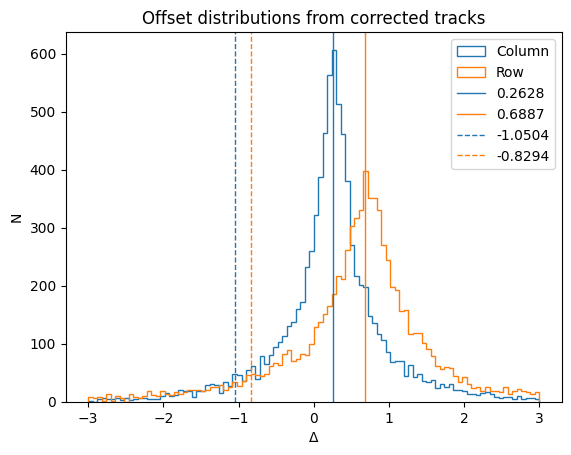

In [550]:
plt.title("Offset distributions from corrected tracks")
plt.hist(dcol, range=(-3, 3), histtype="step", bins=100, label="Column", color="tab:blue")
plt.hist(drow, range=(-3, 3), histtype="step", bins=100, label="Row", color="tab:orange")

plt.axvline(np.median(dcol), color="tab:blue", lw=1, label=f"{np.median(dcol):.4f}")
plt.axvline(np.median(drow), color="tab:orange", lw=1, label=f"{np.median(drow):.4f}")

plt.axvline(np.median(offset_col.loc[:, (str(camera), str(ccd))].values), 
            ls="--", color="tab:blue", lw=1, 
            label=f"{np.median(offset_col.loc[:, (str(camera), str(ccd))].values):.4f}")
plt.axvline(np.median(offset_row.loc[:, (str(camera), str(ccd))].values), 
            ls="--", color="tab:orange", lw=1, 
            label=f"{np.median(offset_row.loc[:, (str(camera), str(ccd))].values):.4f}")
plt.legend()
plt.xlabel("$\Delta$")
plt.ylabel("N")
plt.show()

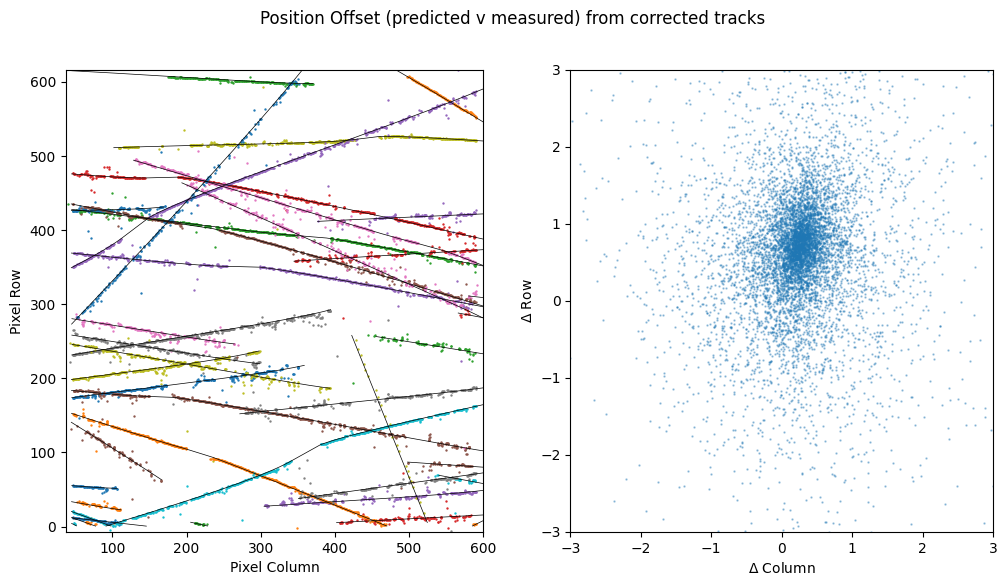

In [535]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle("Position Offset (predicted v measured) from corrected tracks")
for aid in track_from_data.keys():
    ax[0].plot(sb_ephems_hires[aid].column, sb_ephems_hires[aid].row, lw=0.5, c="k")
    ax[0].scatter(centroids_dict[aid].column, centroids_dict[aid].row, s=0.5)

    ax[1].scatter(offsets[aid].column, offsets[aid].row, s=0.5, alpha=.4, c="tab:blue")

ax[0].set_xlim(cube_col.min() - 10, cube_col.max() + 10)
ax[0].set_ylim(cube_row.min() - 10, cube_row.max() + 10)
ax[0].set_aspect('equal', 'box')
ax[0].set_xlabel("Pixel Column")
ax[0].set_ylabel("Pixel Row")

ax[1].set_xlim(-3, 3)
ax[1].set_ylim(-3, 3)
ax[1].set_xlabel("$\Delta$ Column")
ax[1].set_ylabel("$\Delta$ Row")

plt.show()